# VT Landscape

Author: @haewon.yum

**Objective**: Comparative analysis across regions on VT ratio to see if there's any difference between offices and target countires in terms of VT install rate.

**Scope** (this notebook):
- VT install ratio at a campaign level
- across offices + top target countires

**Out of scope** :
- //

**Key Tables**:
- //


---
Ref: 

In [40]:
#@title Environment Setup

from google.cloud import bigquery

import os
import pandas as pd
import numpy as np
import datetime
import warnings
warnings.filterwarnings('ignore')

# plot
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


client = bigquery.Client(project='moloco-ods')

def process_query(input_query):
    job_config = bigquery.QueryJobConfig()
    query_job = client.query(input_query, job_config=job_config)
    df_return = query_job.result().to_dataframe()
    return df_return

def process_query_be(input_query):
    job_config = bigquery.QueryJobConfig()
    query_job = client.query(input_query, job_config=job_config)
    print(f"Submitted job: {query_job.job_id}")
    return query_job

def fetch_result(query_job):
    try:
        if query_job.done():
            if query_job.error_result:
                print(f"Job {query_job.job_id} failed: {query_job.error_result}")
                return {"status": "error", "job_id": query_job.job_id, "error": query_job.error_result}
            else:
                print(f"Job {query_job.job_id} is complete!")
                df_return = query_job.result().to_dataframe()
                return {"status": "success", "job_id": query_job.job_id, "data": df_return}
        else:
            print(f"Job {query_job.job_id} is still running...")
            return None
    except Exception as e:
        print(f"Job {query_job.job_id} raised an exception: {e}")
        return {"status": "exception", "job_id": query_job.job_id, "error": str(e)}

In [41]:
START_DATE = '2026-01-01'
END_DATE = '2026-01-31'

In [42]:
#@title Top 10 countries by spend

top_countries_query = f"""
    SELECT
        campaign.country,
        SUM(gross_spend_usd) AS total_spend
    FROM `moloco-ae-view.athena.fact_dsp_core`
    WHERE
        date_utc BETWEEN '{START_DATE}' AND '{END_DATE}'
        AND advertiser.office IN ('KOR', 'JPN','USA','EMEA','SGP','CHN','IND')
    GROUP BY 1
    ORDER BY 2 DESC
    LIMIT 10
"""

df_top_countries = process_query(top_countries_query)
top_countries = df_top_countries['country'].tolist()
top_countries_str = ", ".join(f"'{c}'" for c in top_countries)

print(f"Top 10 countries by spend: {top_countries}")
print(f"SQL filter: ({top_countries_str})")

Top 10 countries by spend: ['USA', 'KOR', 'JPN', 'GBR', 'DEU', 'FRA', 'CAN', 'RUS', 'BRA', 'ITA']
SQL filter: ('USA', 'KOR', 'JPN', 'GBR', 'DEU', 'FRA', 'CAN', 'RUS', 'BRA', 'ITA')


## Step 1-1. VT ratio by office and target countries as a whole

In [43]:
vt_query = f"""
    SELECT
        advertiser.office,
        campaign.country,
        SUM(installs_vt) AS installs_vt, 
        SUM(installs) AS installs,
        SAFE_DIVIDE(SUM(installs_vt), SUM(installs)) as vt_ratio
    FROM `moloco-ae-view.athena.fact_dsp_core`
    WHERE 
        date_utc BETWEEN '2026-01-01' AND '2026-01-31'        
        AND advertiser.office IN ('KOR', 'JPN','USA','EMEA','SGP','CHN','IND')
        AND campaign.country IN ({top_countries_str})
    GROUP BY 1, 2

"""

df_vt = process_query(vt_query)

df_vt.head()

,office,country,installs_vt,installs,vt_ratio
0,CHN,GBR,75009,650854,0.115247
1,EMEA,GBR,217120,806149,0.269330
2,EMEA,ITA,70295,634138,0.110851
3,SGP,GBR,17810,52099,0.341849
4,SGP,RUS,8116,27938,0.290500


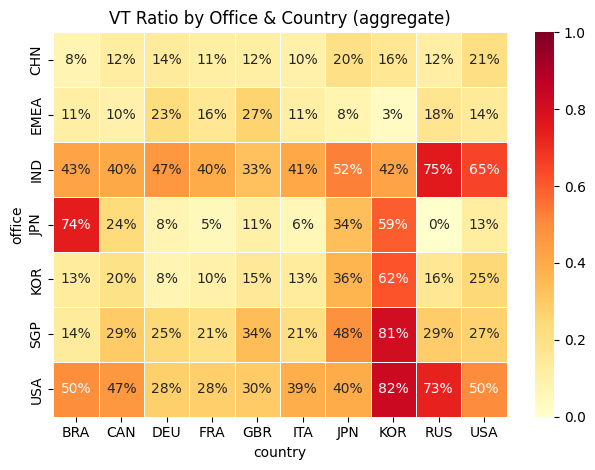

In [44]:
# draw a heatmap by vt_ratio
sns.heatmap(
    df_vt.pivot(index='office', columns='country', values='vt_ratio'),
    annot=True, fmt='.0%', cmap='YlOrRd', vmin=0, vmax=1,
    linewidths=0.5
)
plt.title('VT Ratio by Office & Country (aggregate)')
plt.tight_layout()
plt.show()

## Step 1-2. VT ratio by OS (iOS vs Android)

In [45]:
vt_query_os = f"""
    SELECT
        advertiser.office,
        campaign.country,
        UPPER(campaign.os) AS os,
        SUM(installs_vt) AS installs_vt,
        SUM(installs) AS installs,
        SAFE_DIVIDE(SUM(installs_vt), SUM(installs)) AS vt_ratio
    FROM `moloco-ae-view.athena.fact_dsp_core`
    WHERE
        date_utc BETWEEN '{START_DATE}' AND '{END_DATE}'
        AND advertiser.office IN ('KOR', 'JPN', 'USA', 'EMEA', 'SGP', 'CHN', 'IND')
        AND campaign.country IN ({top_countries_str})
        AND UPPER(campaign.os) IN ('IOS', 'ANDROID')
    GROUP BY 1, 2, 3
"""

df_vt_os = process_query(vt_query_os)
print(f"✅ {len(df_vt_os)} rows")
df_vt_os.head()

✅ 140 rows


,office,country,os,installs_vt,installs,vt_ratio
0,USA,ITA,IOS,4816,11006,0.437580
1,SGP,FRA,IOS,6929,31330,0.221162
2,JPN,BRA,IOS,3,28,0.107143
3,USA,KOR,ANDROID,48811,55147,0.885107
4,IND,GBR,IOS,1535,3962,0.387431


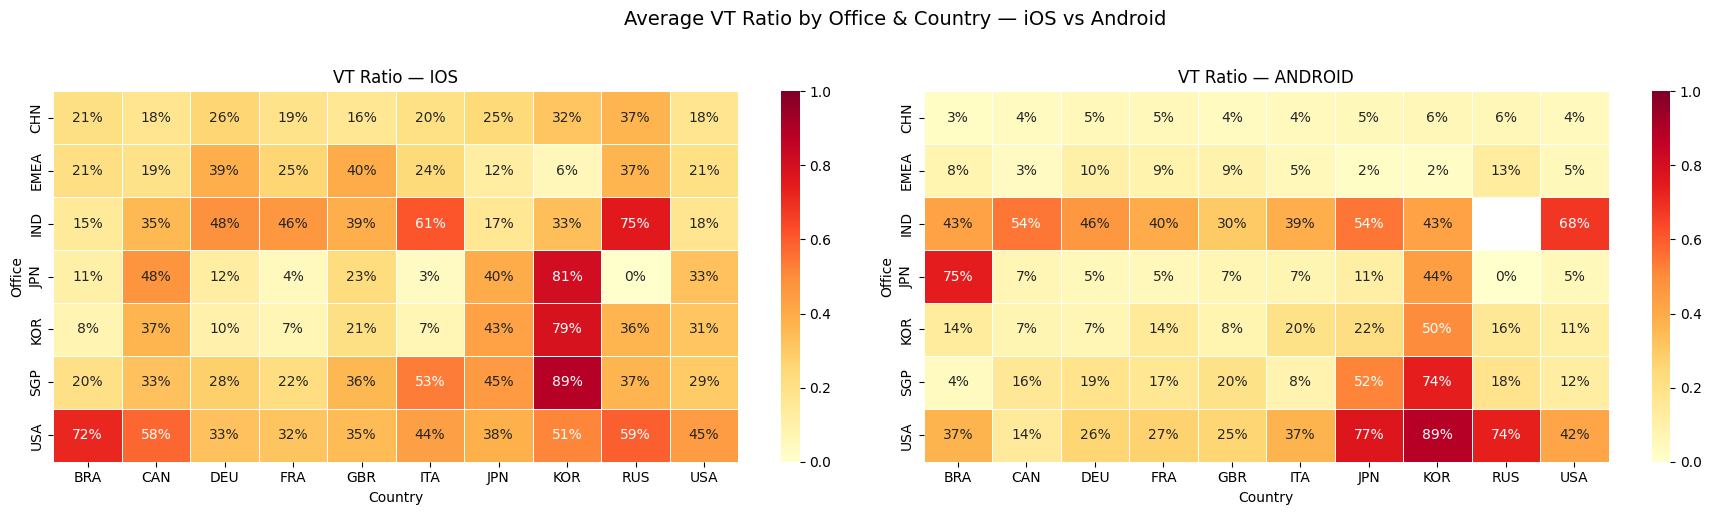

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, os_name in zip(axes, ['IOS', 'ANDROID']):
    pivot = (
        df_vt_os[df_vt_os['os'] == os_name]
        .pivot_table(index='office', columns='country', values='vt_ratio', aggfunc='mean')
    )
    sns.heatmap(pivot, annot=True, fmt='.0%', cmap='YlOrRd', vmin=0, vmax=1,
                ax=ax, linewidths=0.5, mask=pivot.isna())
    ax.set_title(f'VT Ratio — {os_name}')
    ax.set_ylabel('Office')
    ax.set_xlabel('Country')

plt.suptitle('Average VT Ratio by Office & Country — iOS vs Android', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Step 1-3. VT ratio by target country, across OS

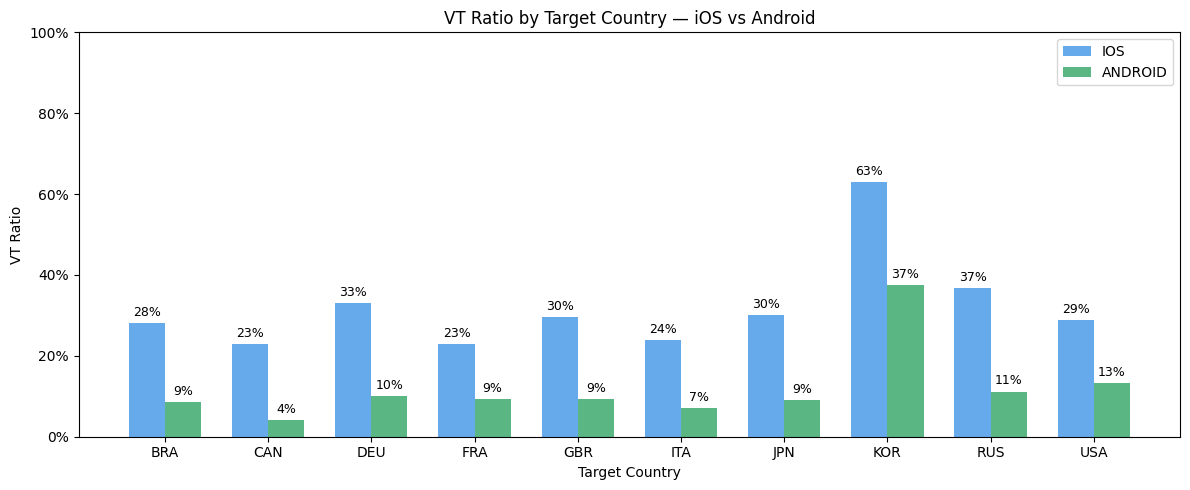

In [47]:
df_vt_country_os = (
    df_vt_os
    .groupby(['country', 'os'])
    .apply(lambda g: pd.Series({
        'vt_ratio': g['installs_vt'].sum() / g['installs'].sum()
            if g['installs'].sum() > 0 else float('nan')
    }))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

countries = df_vt_country_os['country'].unique()
os_list = ['IOS', 'ANDROID']
colors = {'IOS': '#4C9BE8', 'ANDROID': '#3DAA6D'}
x = np.arange(len(countries))
width = 0.35

for i, os_name in enumerate(os_list):
    vals = [
        df_vt_country_os.loc[
            (df_vt_country_os['country'] == c) & (df_vt_country_os['os'] == os_name),
            'vt_ratio'
        ].values[0] if ((df_vt_country_os['country'] == c) & (df_vt_country_os['os'] == os_name)).any() else float('nan')
        for c in countries
    ]
    bars = ax.bar(x + (i - 0.5) * width, vals, width, label=os_name, color=colors[os_name], alpha=0.85)
    ax.bar_label(bars, fmt='{:.0%}', padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(countries)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 1)
ax.set_xlabel('Target Country')
ax.set_ylabel('VT Ratio')
ax.set_title('VT Ratio by Target Country — iOS vs Android')
ax.legend()
plt.tight_layout()
plt.show()

## Step 2-1. VT ratio at bundle level

In [48]:
vt_query_bundle = f"""
    SELECT
        advertiser.office,
        campaign.country,
        product.app_market_bundle,
        SUM(installs_vt) AS installs_vt, 
        SUM(installs) AS installs,
        SAFE_DIVIDE(SUM(installs_vt), SUM(installs)) as vt_ratio
    FROM `moloco-ae-view.athena.fact_dsp_core`
    WHERE 
        date_utc BETWEEN '2026-01-01' AND '2026-01-31'        
        AND advertiser.office IN ('KOR', 'JPN','USA','EMEA','SGP','CHN','IND')
        AND campaign.country IN ({top_countries_str})
    GROUP BY 1, 2, 3

"""

df_vt_bundle = process_query(vt_query_bundle)

df_vt_bundle.head()


,office,country,app_market_bundle,installs_vt,installs,vt_ratio
0,CHN,BRA,com.client.tenderu.android,0,1020,0.000000
1,CHN,BRA,com.kosoj.woodenblast,0,0,NaN
2,CHN,BRA,6752887466,0,107,0.000000
3,CHN,BRA,com.dating.ai,1960,20818,0.094149
4,CHN,BRA,6754167179,0,0,NaN


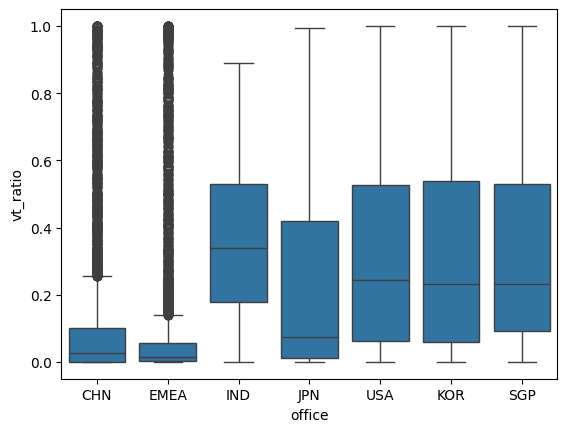

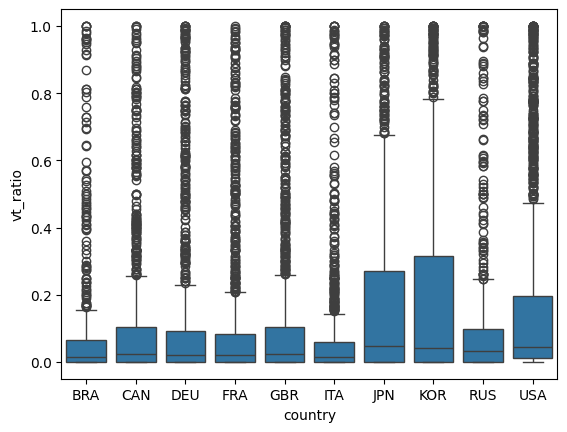

In [49]:
#draw distribution of vt_ratio by office and target country
sns.boxplot(x='office', y='vt_ratio', data=df_vt_bundle)
plt.show()

#draw distribution of vt_ratio by office and target country
sns.boxplot(x='country', y='vt_ratio', data=df_vt_bundle)
plt.show()

## Step 2-2. VT ratio at campaign level

In [50]:
vt_query = f"""
    SELECT
        advertiser.office,
        campaign.country,
        campaign_id,
        SUM(installs_vt) AS installs_vt, 
        SUM(installs) AS installs,
        SAFE_DIVIDE(SUM(installs_vt), SUM(installs)) as vt_ratio
    FROM `moloco-ae-view.athena.fact_dsp_core`
    WHERE 
        date_utc BETWEEN '2026-01-01' AND '2026-01-31'        
        AND advertiser.office IN ('KOR', 'JPN','USA','EMEA','SGP','CHN','IND')
        AND campaign.country IN ({top_countries_str})
    GROUP BY 1, 2, 3

"""

df_vt_campaign = process_query(vt_query)

df_vt_campaign.head()

,office,country,campaign_id,installs_vt,installs,vt_ratio
0,EMEA,DEU,wgCKr2NbkDbaeG8A,8,166,0.048193
1,CHN,USA,gxsYtWyhuyyQnNwC,3199,4671,0.684864
2,EMEA,USA,P02VyjzkkTztpUgw,185,1123,0.164737
3,KOR,DEU,wCWzgo5RifS9mFMs,10,1403,0.007128
4,CHN,USA,nFqYnNnnDEFxzWYJ,499,593,0.841484


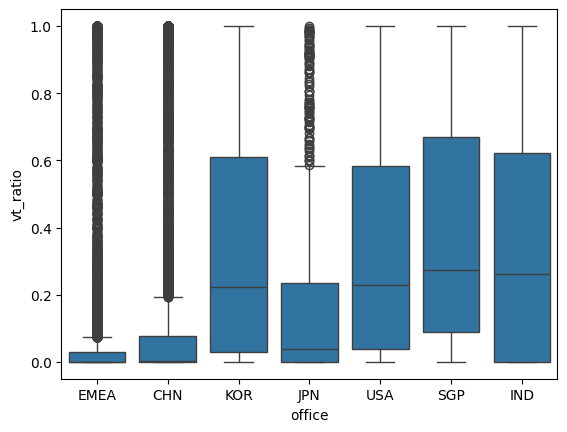

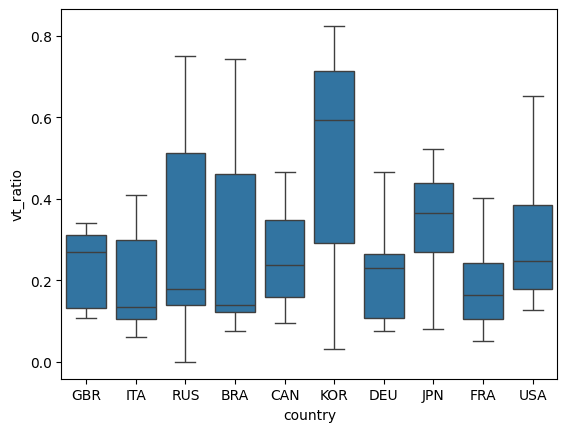

In [51]:
#@title VT ratio distribution by office and target 


# draw box plot by office
sns.boxplot(x='office', y='vt_ratio', data=df_vt_campaign)
plt.show()

# draw box plot by target country
sns.boxplot(x='country', y='vt_ratio', data=df_vt)
plt.show()

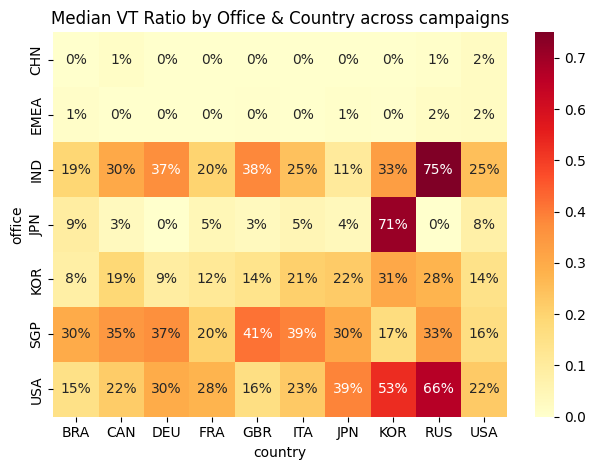

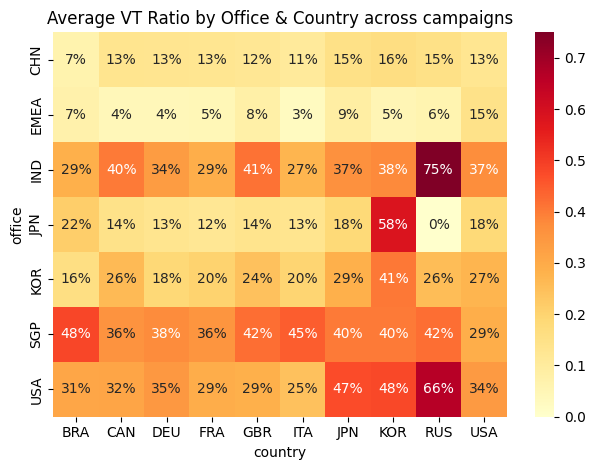

In [52]:
# draw a heatmap by vt_ratio with median value of vt_ratio

pivot_median = df_vt_campaign.pivot_table(index='office', columns='country', values='vt_ratio', aggfunc='median')

# please make the format with percentage
sns.heatmap(pivot_median, annot=True, fmt='.0%', cmap='YlOrRd')
plt.title('Median VT Ratio by Office & Country across campaigns')
plt.tight_layout()
plt.show()

pivot_avg = df_vt_campaign.pivot_table(index='office', columns='country', values='vt_ratio', aggfunc='mean')

# please make the format with percentage
sns.heatmap(pivot_avg, annot=True, fmt='.0%', cmap='YlOrRd')
plt.title('Average VT Ratio by Office & Country across campaigns')
plt.tight_layout()
plt.show()

## Step 2-3. VT ratio at campaign level by OS (iOS vs Android)

In [58]:
vt_query_campaign_os = f"""
    SELECT
        advertiser.office,
        campaign.country,
        campaign_id,
        UPPER(campaign.os) AS os,
        SUM(installs_vt) AS installs_vt,
        SUM(installs) AS installs,
        SAFE_DIVIDE(SUM(installs_vt), SUM(installs)) AS vt_ratio
    FROM `moloco-ae-view.athena.fact_dsp_core`
    WHERE
        date_utc BETWEEN '{START_DATE}' AND '{END_DATE}'
        AND advertiser.office IN ('KOR', 'JPN', 'USA', 'EMEA', 'SGP', 'CHN', 'IND')
        AND campaign.country IN ({top_countries_str})
        AND UPPER(campaign.os) IN ('IOS', 'ANDROID')
    GROUP BY 1, 2, 3, 4
"""

df_vt_campaign_os = process_query(vt_query_campaign_os)
print(f"✅ {len(df_vt_campaign_os)} rows")
df_vt_campaign_os.head()

✅ 53148 rows


,office,country,campaign_id,os,installs_vt,installs,vt_ratio
0,EMEA,BRA,RZkLtivWGQLSjKmz,ANDROID,0,0,NaN
1,EMEA,BRA,hgIlSkSnxo9k66RX,ANDROID,0,0,NaN
2,EMEA,BRA,RzG1OMexjosSpH60,ANDROID,0,0,NaN
3,EMEA,ITA,dgSNTxSPyNpwOy8j,ANDROID,6,1008,0.005952
4,EMEA,ITA,HqPIskpv2z5P8wjx,IOS,0,0,NaN


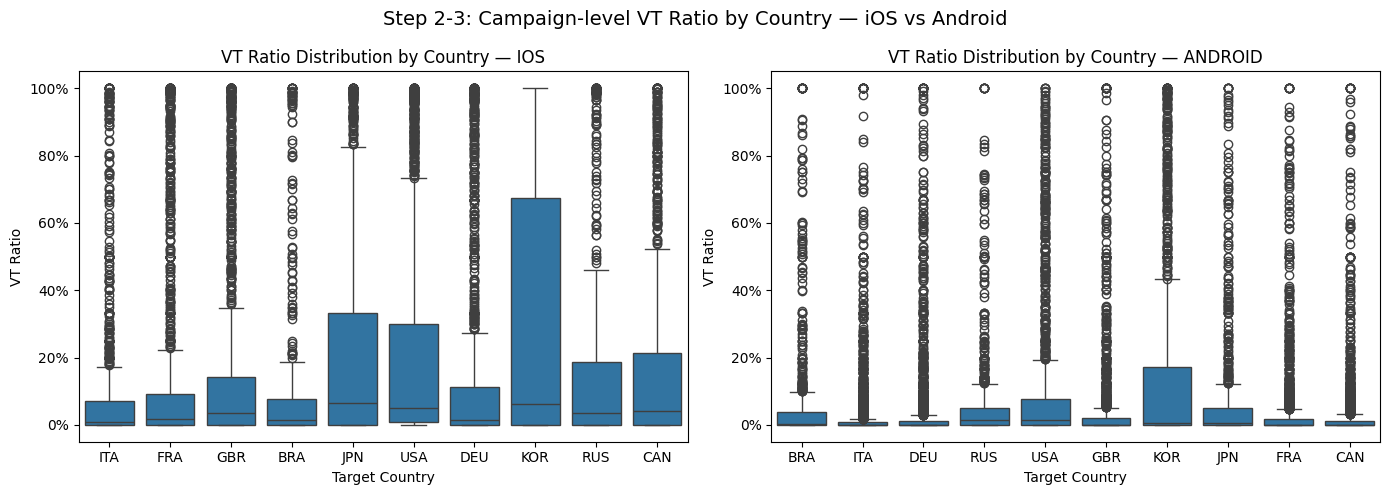

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, os_name in zip(axes, ['IOS', 'ANDROID']):
    df_os = df_vt_campaign_os[df_vt_campaign_os['os'] == os_name]
    sns.boxplot(x='country', y='vt_ratio', data=df_os, ax=ax)
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f'VT Ratio Distribution by Country — {os_name}')
    ax.set_xlabel('Target Country')
    ax.set_ylabel('VT Ratio')

plt.suptitle('Step 2-3: Campaign-level VT Ratio by Country — iOS vs Android', fontsize=14)
plt.tight_layout()
plt.show()

## Step 2-4. Spend by VT ratio bucket — KOR targeting campaigns

In [61]:
vt_query_kor_spend = f"""
    WITH base AS (
        SELECT
            campaign_id,
            UPPER(campaign.os) AS os,
            SUM(gross_spend_usd) AS spend,
            SUM(installs_vt) AS installs_vt,
            SUM(installs) AS installs,
            SAFE_DIVIDE(SUM(installs_vt), SUM(installs)) AS vt_ratio
        FROM `moloco-ae-view.athena.fact_dsp_core`
        WHERE
            date_utc BETWEEN '{START_DATE}' AND '{END_DATE}'
            AND campaign.country = 'KOR'
            AND UPPER(campaign.os) IN ('IOS', 'ANDROID')
        GROUP BY 1, 2
    )
    SELECT * FROM base
    WHERE installs > 0
"""

df_kor_spend = process_query(vt_query_kor_spend)
print(f"✅ {len(df_kor_spend)} rows")

# bucket vt_ratio into 10% bins
df_kor_spend['vt_bucket'] = pd.cut(
    df_kor_spend['vt_ratio'],
    bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    labels=['0-10%', '10-20%', '20-30%', '30-40%', '40-50%',
            '50-60%', '60-70%', '70-80%', '80-90%', '90-100%'],
    include_lowest=True
)

df_kor_spend.head()

✅ 1696 rows


,campaign_id,os,spend,installs_vt,installs,vt_ratio,vt_bucket
0,ikMI4yAC6VK628h7,IOS,23.812764826,2,2,1.000000,90-100%
1,yCEEnCxBxycmTdix,IOS,12144.775960728,948,1306,0.725881,70-80%
2,DvBVo6ViUweSm9BW,ANDROID,7042.012042490,183,290,0.631034,60-70%
3,oqxFwxmLwYbze4dm,ANDROID,320.358869046,0,36,0.000000,0-10%
4,UyliQbPMzNuBY9Qz,ANDROID,12360.852415715,12,431,0.027842,0-10%


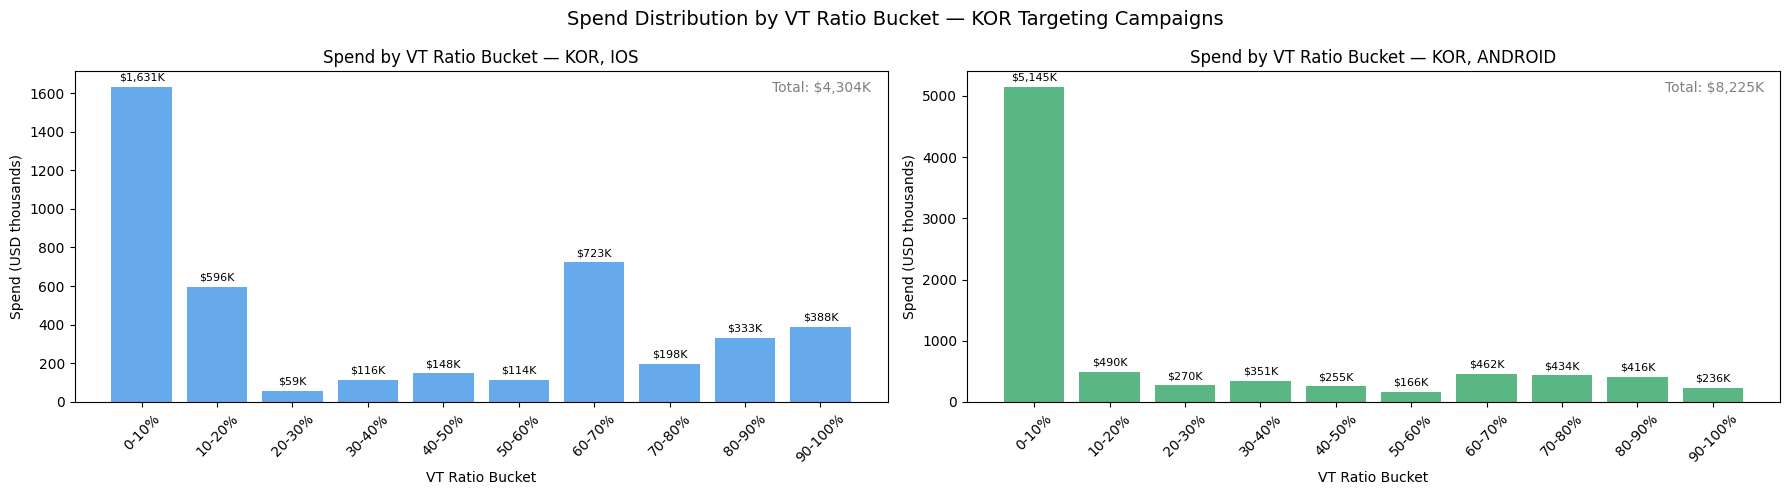

In [62]:
df_bucket_spend = (
    df_kor_spend
    .groupby(['vt_bucket', 'os'], observed=True)['spend']
    .sum()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, os_name in zip(axes, ['IOS', 'ANDROID']):
    df_os = df_bucket_spend[df_bucket_spend['os'] == os_name]
    bars = ax.bar(df_os['vt_bucket'], df_os['spend'] / 1_000, color='#4C9BE8' if os_name == 'IOS' else '#3DAA6D', alpha=0.85)
    ax.bar_label(bars, fmt='${:,.0f}K', padding=3, fontsize=8)
    ax.set_xlabel('VT Ratio Bucket')
    ax.set_ylabel('Spend (USD thousands)')
    ax.set_title(f'Spend by VT Ratio Bucket — KOR, {os_name}')
    ax.tick_params(axis='x', rotation=45)
    total = df_os['spend'].sum()
    ax.text(0.98, 0.97, f'Total: ${total/1_000:,.0f}K', transform=ax.transAxes,
            ha='right', va='top', fontsize=10, color='grey')

plt.suptitle('Spend Distribution by VT Ratio Bucket — KOR Targeting Campaigns', fontsize=14)
plt.tight_layout()
plt.show()

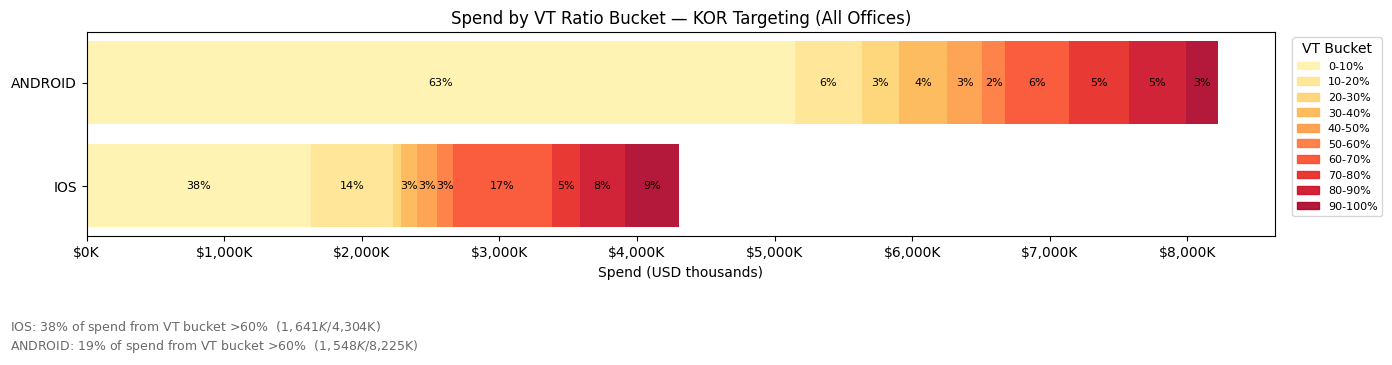

In [74]:
buckets = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%',
           '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']
high_vt_buckets = ['60-70%', '70-80%', '80-90%', '90-100%']

palette = sns.color_palette('YlOrRd', len(buckets))

fig, ax = plt.subplots(figsize=(14, 3))

summary_lines = []
for os_idx, os_name in enumerate(['IOS', 'ANDROID']):
    df_os = df_bucket_spend[df_bucket_spend['os'] == os_name].set_index('vt_bucket')
    total = df_os['spend'].sum()
    high_vt_spend = df_os.loc[df_os.index.isin(high_vt_buckets), 'spend'].sum()
    high_vt_pct = high_vt_spend / total if total > 0 else 0
    summary_lines.append(f"{os_name}: {high_vt_pct:.0%} of spend from VT bucket >60%  (${high_vt_spend/1_000:,.0f}K / ${total/1_000:,.0f}K)")

    left = 0
    for bucket, color in zip(buckets, palette):
        val = df_os.loc[bucket, 'spend'] / 1_000 if bucket in df_os.index else 0
        pct = (val * 1_000) / total if total > 0 else 0
        ax.barh(os_name, val, left=left, color=color, alpha=0.9)
        if pct >= 0.02:
            ax.text(left + val / 2, os_idx, f'{pct:.0%}',
                    ha='center', va='center', fontsize=8, color='black')
        left += val

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x:,.0f}K'))
ax.set_xlabel('Spend (USD thousands)')
ax.set_title('Spend by VT Ratio Bucket — KOR Targeting (All Offices)')

handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.9) for c in palette]
ax.legend(handles, buckets, title='VT Bucket', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
fig.text(0.01, -0.08, '\n'.join(summary_lines), fontsize=9, color='dimgrey', va='top')
plt.show()

## Step 2-4-2. Spend by VT ratio bucket — KOR targeting × KOR office campaigns

In [65]:
vt_query_kor_kor_spend = f"""
    WITH base AS (
        SELECT
            campaign_id,
            UPPER(campaign.os) AS os,
            SUM(gross_spend_usd) AS spend,
            SUM(installs_vt) AS installs_vt,
            SUM(installs) AS installs,
            SAFE_DIVIDE(SUM(installs_vt), SUM(installs)) AS vt_ratio
        FROM `moloco-ae-view.athena.fact_dsp_core`
        WHERE
            date_utc BETWEEN '{START_DATE}' AND '{END_DATE}'
            AND campaign.country = 'KOR'
            AND advertiser.office = 'KOR'
            AND UPPER(campaign.os) IN ('IOS', 'ANDROID')
        GROUP BY 1, 2
    )
    SELECT * FROM base
    WHERE installs > 0
"""

df_kor_kor_spend = process_query(vt_query_kor_kor_spend)
print(f"✅ {len(df_kor_kor_spend)} rows")

df_kor_kor_spend['vt_bucket'] = pd.cut(
    df_kor_kor_spend['vt_ratio'],
    bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    labels=['0-10%', '10-20%', '20-30%', '30-40%', '40-50%',
            '50-60%', '60-70%', '70-80%', '80-90%', '90-100%'],
    include_lowest=True
)

df_kor_kor_spend.head()

✅ 489 rows


,campaign_id,os,spend,installs_vt,installs,vt_ratio,vt_bucket
0,BJbUOGHQ4EA6vEqy,IOS,11251.778453196,569,4068,0.139872,10-20%
1,kCh2qC5jQywuYtQL,IOS,2143.853826336,6219,6436,0.966283,90-100%
2,M6VNxQ68DL91j8hQ,ANDROID,0E-9,0,1,0.000000,0-10%
3,vIr53hPcMsXDUii3,IOS,6438.101584235,2455,6890,0.356313,30-40%
4,tjtTmJfyAiKzCe6h,IOS,5524.056326053,6990,7080,0.987288,90-100%


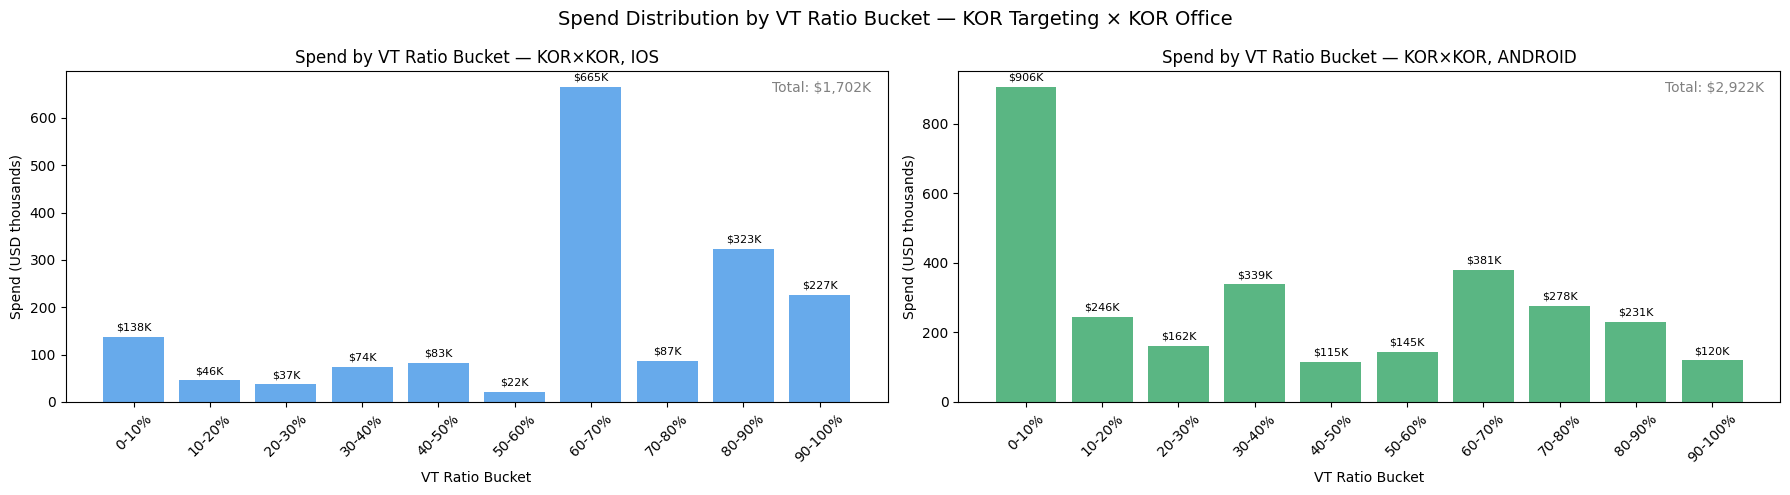

In [71]:
df_kor_kor_bucket = (
    df_kor_kor_spend
    .groupby(['vt_bucket', 'os'], observed=True)['spend']
    .sum()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, os_name in zip(axes, ['IOS', 'ANDROID']):
    df_os = df_kor_kor_bucket[df_kor_kor_bucket['os'] == os_name]
    bars = ax.bar(df_os['vt_bucket'], df_os['spend'] / 1_000,
                  color='#4C9BE8' if os_name == 'IOS' else '#3DAA6D', alpha=0.85)
    ax.bar_label(bars, fmt='${:,.0f}K', padding=3, fontsize=8)
    ax.set_xlabel('VT Ratio Bucket')
    ax.set_ylabel('Spend (USD thousands)')
    ax.set_title(f'Spend by VT Ratio Bucket — KOR×KOR, {os_name}')
    ax.tick_params(axis='x', rotation=45)
    total = df_os['spend'].sum()
    ax.text(0.98, 0.97, f'Total: ${total/1_000:,.0f}K', transform=ax.transAxes,
            ha='right', va='top', fontsize=10, color='grey')

plt.suptitle('Spend Distribution by VT Ratio Bucket — KOR Targeting × KOR Office', fontsize=14)
plt.tight_layout()
plt.show()

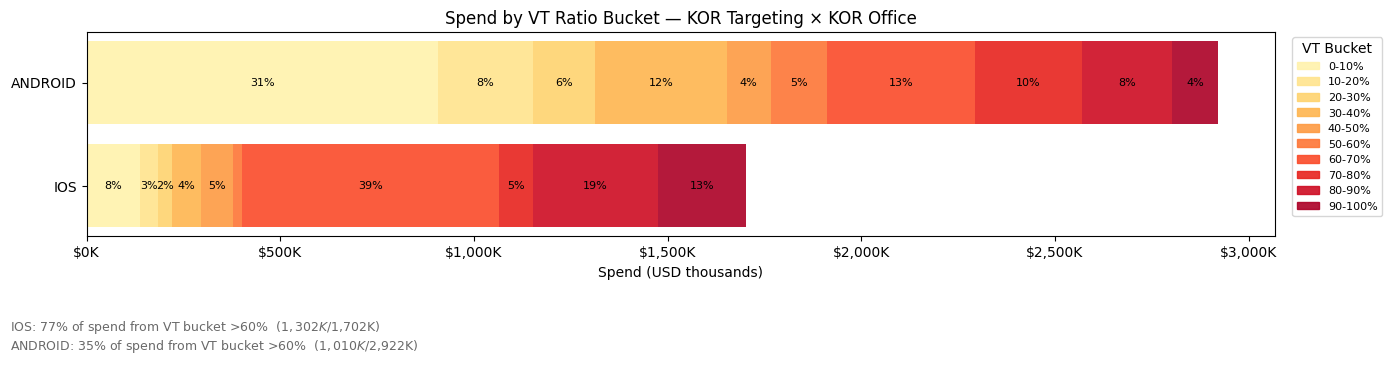

In [75]:
buckets = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%',
           '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']
high_vt_buckets = ['60-70%', '70-80%', '80-90%', '90-100%']

palette = sns.color_palette('YlOrRd', len(buckets))

fig, ax = plt.subplots(figsize=(14, 3))

summary_lines = []
for os_idx, os_name in enumerate(['IOS', 'ANDROID']):
    df_os = df_kor_kor_bucket[df_kor_kor_bucket['os'] == os_name].set_index('vt_bucket')
    total = df_os['spend'].sum()
    high_vt_spend = df_os.loc[df_os.index.isin(high_vt_buckets), 'spend'].sum()
    high_vt_pct = high_vt_spend / total if total > 0 else 0
    summary_lines.append(f"{os_name}: {high_vt_pct:.0%} of spend from VT bucket >60%  (${high_vt_spend/1_000:,.0f}K / ${total/1_000:,.0f}K)")

    left = 0
    for bucket, color in zip(buckets, palette):
        val = df_os.loc[bucket, 'spend'] / 1_000 if bucket in df_os.index else 0
        pct = (val * 1_000) / total if total > 0 else 0
        ax.barh(os_name, val, left=left, color=color, alpha=0.9)
        if pct >= 0.02:
            ax.text(left + val / 2, os_idx, f'{pct:.0%}',
                    ha='center', va='center', fontsize=8, color='black')
        left += val

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x:,.0f}K'))
ax.set_xlabel('Spend (USD thousands)')
ax.set_title('Spend by VT Ratio Bucket — KOR Targeting × KOR Office')

handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.9) for c in palette]
ax.legend(handles, buckets, title='VT Bucket', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
fig.text(0.01, -0.08, '\n'.join(summary_lines), fontsize=9, color='dimgrey', va='top')
plt.show()

## Step 3-1. VT ratio by cr format mix

In [55]:
query_cr_mix = f"""
    SELECT
        advertiser.office,
        campaign.country,
        campaign_id,
        SUM(if(creative.format = 'ib', installs_vt, 0)) as installs_vt_ib,
        SUM(if(creative.format = 'ib', installs, 0)) as installs_ib,
        SAFE_DIVIDE(SUM(if(creative.format = 'ib', installs_vt, 0)), SUM(if(creative.format = 'ib', installs, 0))) as vt_ratio_ib,
        SUM(if(creative.format IN ('vi', 'ri', 'nv'), installs_vt, 0)) as installs_vt_rich,
        SUM(if(creative.format IN ('vi', 'ri', 'nv'), installs, 0)) as installs_rich,
        SAFE_DIVIDE(SUM(if(creative.format IN ('vi', 'ri', 'nv'), installs_vt, 0)), SUM(if(creative.format IN ('vi', 'ri', 'nv'), installs, 0))) as vt_ratio_rich,
        SUM(installs_vt) AS installs_vt, 
        SUM(installs) AS installs,
        SAFE_DIVIDE(SUM(installs_vt), SUM(installs)) as vt_ratio
    FROM `moloco-ae-view.athena.fact_dsp_creative`
    WHERE
        date_utc BETWEEN '2026-01-01' AND '2026-01-31'
        AND advertiser.office IN ('KOR', 'JPN','USA','EMEA','SGP','CHN','IND')
        AND campaign.country IN ({top_countries_str})
    GROUP BY 1, 2, 3

"""

df_cr_mix = process_query(query_cr_mix)

df_cr_mix.head()


,office,country,campaign_id,installs_vt_ib,installs_ib,vt_ratio_ib,installs_vt_rich,installs_rich,vt_ratio_rich,installs_vt,installs,vt_ratio
0,EMEA,USA,x9TMvF2XXUu75GKC,0,0,NaN,127,5077,0.025015,133,5126,0.025946
1,USA,JPN,GhxWGhvF7ZOX8J4O,2247,2322,0.967700,415,17268,0.024033,3313,20255,0.163565
2,CHN,DEU,LCVtHhWETpxBQrSV,23,42,0.547619,0,45,0.000000,27,92,0.293478
3,CHN,DEU,flxpFdymixzzcuVC,5,5,1.000000,1,53,0.018868,13,75,0.173333
4,EMEA,FRA,NKzJA6qzyTCTC2cC,0,0,NaN,7,946,0.007400,7,946,0.007400


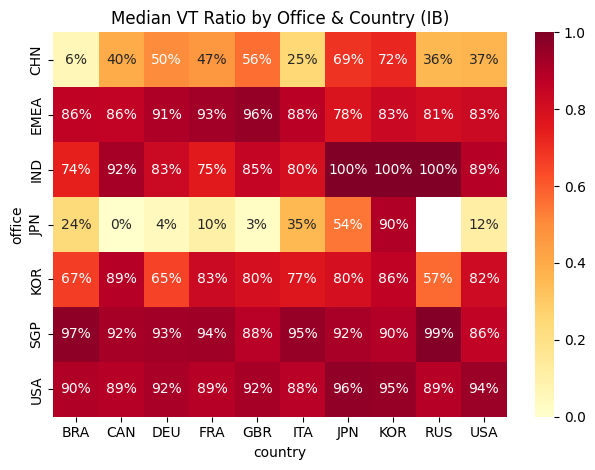

Text(0.5, 1.0, 'Median VT Ratio by Office & Country (Rich formats: vi/ri/nv)')

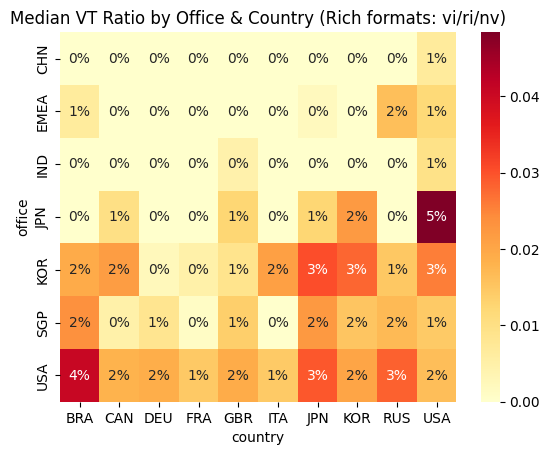

In [56]:
# draw a heatmap by vt_ratio_ib and vt_ratio_rich

pivot_median_ib = df_cr_mix.pivot_table(index='office', columns='country', values='vt_ratio_ib', aggfunc='median')
pivot_median_rich = df_cr_mix.pivot_table(index='office', columns='country', values='vt_ratio_rich', aggfunc='median')

sns.heatmap(pivot_median_ib, annot=True, fmt='.0%', cmap='YlOrRd')
plt.title('Median VT Ratio by Office & Country (IB)')
plt.tight_layout()
plt.show()

sns.heatmap(pivot_median_rich, annot=True, fmt='.0%', cmap='YlOrRd')
plt.title('Median VT Ratio by Office & Country (Rich formats: vi/ri/nv)')

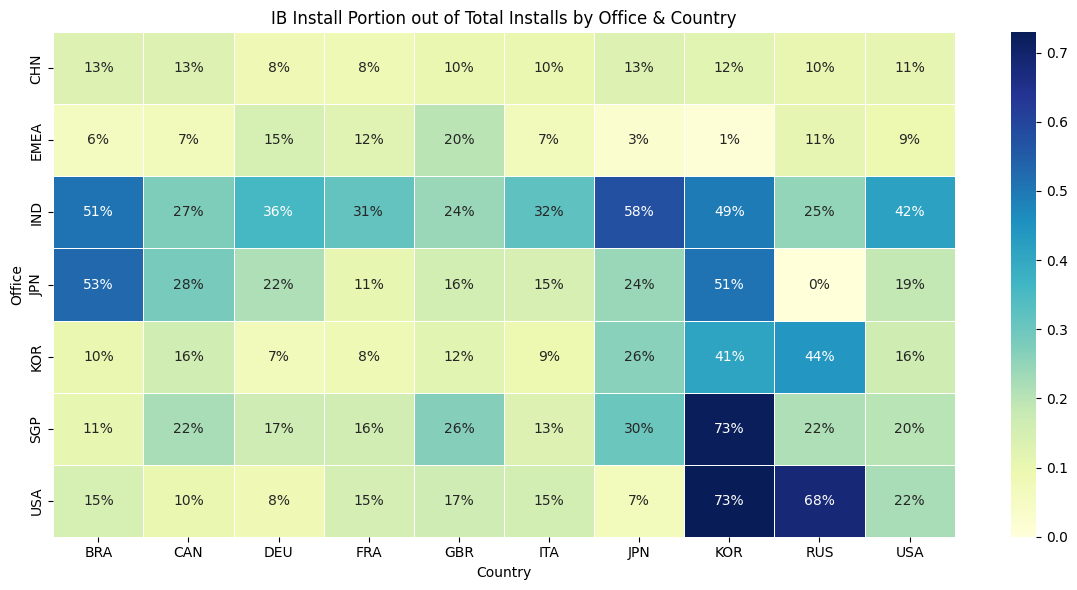

In [57]:
# ib install portion out of total installs across offices and target countries (not about VT ratio)

df_ib_portion = (
    df_cr_mix
    .groupby(['office', 'country'])
    .agg(installs_ib=('installs_ib', 'sum'), installs=('installs', 'sum'))
    .assign(ib_install_ratio=lambda x: x['installs_ib'] / x['installs'])
    .reset_index()
)

pivot_ib_portion = df_ib_portion.pivot_table(
    index='office', columns='country', values='ib_install_ratio', aggfunc='mean'
).astype(float)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_ib_portion, annot=True, fmt='.0%', cmap='YlGnBu', linewidths=0.5, mask=pivot_ib_portion.isna())
plt.title('IB Install Portion out of Total Installs by Office & Country')
plt.ylabel('Office')
plt.xlabel('Country')
plt.tight_layout()
plt.show()


## Step 3-2. VT ratio by cr format mix — by OS (iOS vs Android)

In [83]:
query_cr_mix_os = f"""
    WITH base AS (
        SELECT
            advertiser.office,
            campaign.country,
            campaign_id,
            UPPER(campaign.os) AS os,
            SUM(IF(creative.format = 'ib', installs_vt, 0)) AS installs_vt_ib,
            SUM(IF(creative.format = 'ib', installs, 0)) AS installs_ib,
            SAFE_DIVIDE(SUM(IF(creative.format = 'ib', installs_vt, 0)), SUM(IF(creative.format = 'ib', installs, 0))) AS vt_ratio_ib,
            SUM(IF(creative.format IN ('vi', 'ri', 'nv'), installs_vt, 0)) AS installs_vt_rich,
            SUM(IF(creative.format IN ('vi', 'ri', 'nv'), installs, 0)) AS installs_rich,
            SAFE_DIVIDE(SUM(IF(creative.format IN ('vi', 'ri', 'nv'), installs_vt, 0)), SUM(IF(creative.format IN ('vi', 'ri', 'nv'), installs, 0))) AS vt_ratio_rich,
            SUM(installs_vt) AS installs_vt,
            SUM(installs) AS installs,
            SAFE_DIVIDE(SUM(installs_vt), SUM(installs)) AS vt_ratio
        FROM `moloco-ae-view.athena.fact_dsp_creative`
        WHERE
            date_utc BETWEEN '{START_DATE}' AND '{END_DATE}'
            AND advertiser.office IN ('KOR', 'JPN', 'USA', 'EMEA', 'SGP', 'CHN', 'IND')
            AND campaign.country IN ({top_countries_str})
            AND UPPER(campaign.os) IN ('IOS', 'ANDROID')
        GROUP BY 1, 2, 3, 4
    )
    SELECT * FROM base WHERE installs > 0
"""

df_cr_mix_os = process_query(query_cr_mix_os)
print(f"✅ {len(df_cr_mix_os)} rows")
df_cr_mix_os.head()

✅ 30879 rows


,office,country,campaign_id,os,installs_vt_ib,installs_ib,vt_ratio_ib,installs_vt_rich,installs_rich,vt_ratio_rich,installs_vt,installs,vt_ratio
0,CHN,CAN,LrvtAl28eMJDFy5A,IOS,35,37,0.945946,2,89,0.022472,44,134,0.328358
1,CHN,USA,LrvtAl28eMJDFy5A,IOS,106,110,0.963636,14,556,0.025180,145,692,0.209538
2,CHN,GBR,LrvtAl28eMJDFy5A,IOS,49,52,0.942308,4,140,0.028571,61,200,0.305000
3,EMEA,CAN,ePPkMUz7fJODHbjs,IOS,25,36,0.694444,5,159,0.031447,382,566,0.674912
4,CHN,DEU,hTtnUlRThnoK73HP,ANDROID,0,0,NaN,15,1538,0.009753,60,1600,0.037500


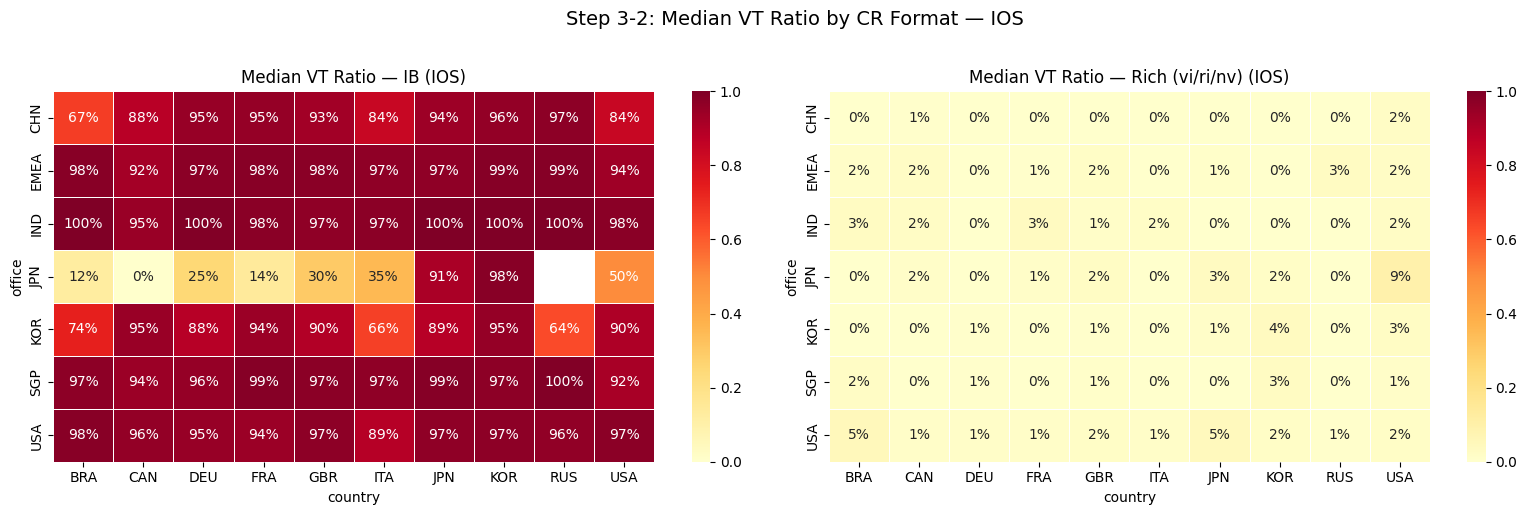

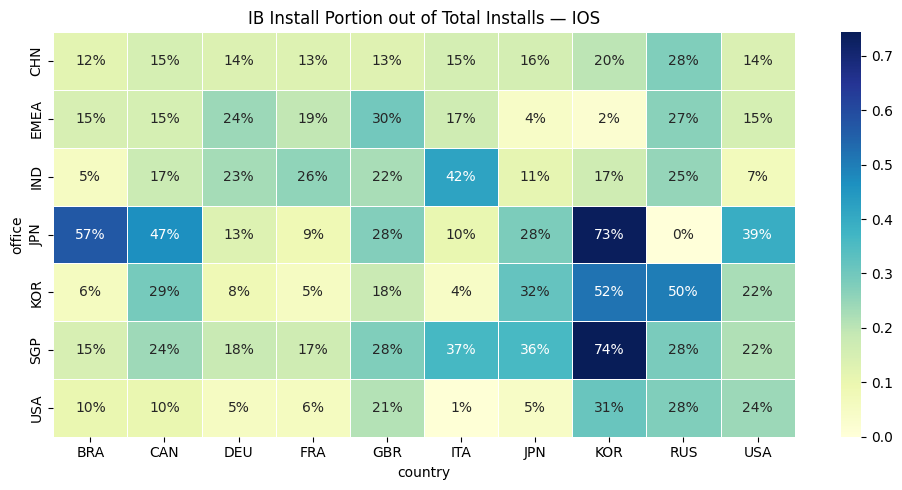

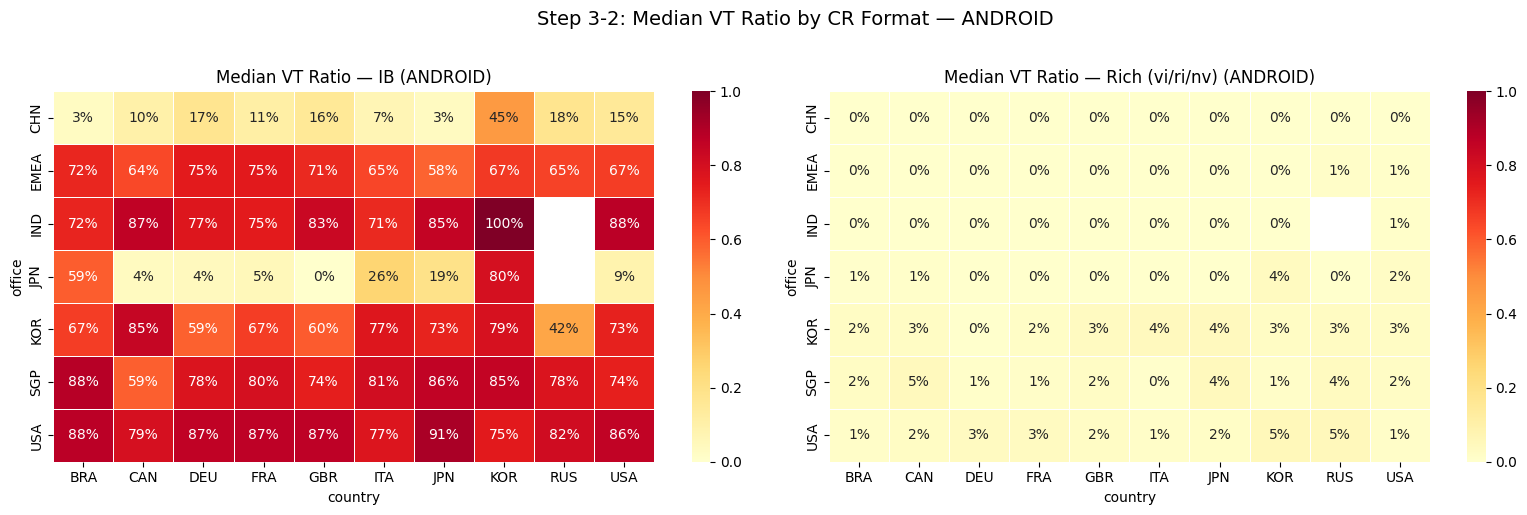

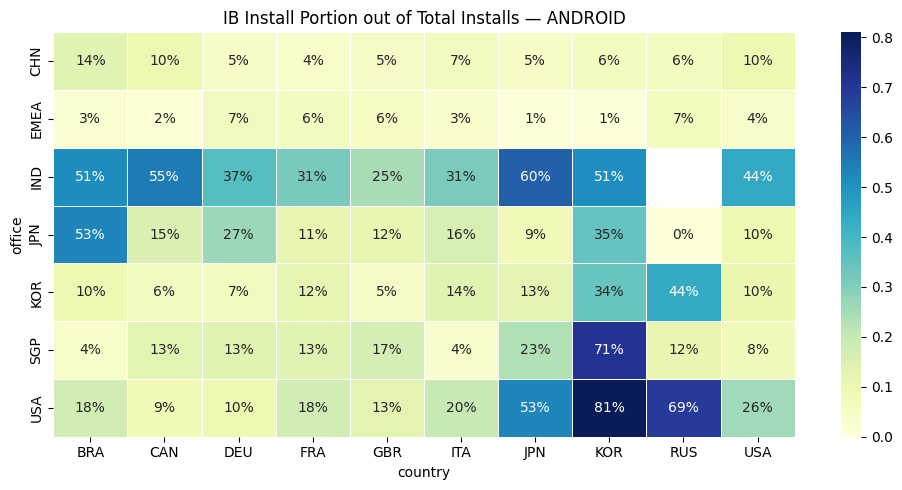

In [84]:
for os_name in ['IOS', 'ANDROID']:
    df_os = df_cr_mix_os[df_cr_mix_os['os'] == os_name]

    pivot_ib   = df_os.pivot_table(index='office', columns='country', values='vt_ratio_ib',   aggfunc='median')
    pivot_rich = df_os.pivot_table(index='office', columns='country', values='vt_ratio_rich', aggfunc='median')
    df_ib_por  = (
        df_os.groupby(['office', 'country'])
        .agg(installs_ib=('installs_ib', 'sum'), installs=('installs', 'sum'))
        .assign(ib_install_ratio=lambda x: x['installs_ib'] / x['installs'])
        .reset_index()
    )
    pivot_ib_por = df_ib_por.pivot_table(
        index='office', columns='country', values='ib_install_ratio', aggfunc='mean'
    ).astype(float)

    # Chart 1: VT ratio by format
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.heatmap(pivot_ib, annot=True, fmt='.0%', cmap='YlOrRd', vmin=0, vmax=1,
                linewidths=0.5, mask=pivot_ib.isna(), ax=axes[0])
    axes[0].set_title(f'Median VT Ratio — IB ({os_name})')
    sns.heatmap(pivot_rich, annot=True, fmt='.0%', cmap='YlOrRd', vmin=0, vmax=1,
                linewidths=0.5, mask=pivot_rich.isna(), ax=axes[1])
    axes[1].set_title(f'Median VT Ratio — Rich (vi/ri/nv) ({os_name})')
    plt.suptitle(f'Step 3-2: Median VT Ratio by CR Format — {os_name}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # Chart 2: IB install portion
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(pivot_ib_por, annot=True, fmt='.0%', cmap='YlGnBu',
                linewidths=0.5, mask=pivot_ib_por.isna(), ax=ax)
    ax.set_title(f'IB Install Portion out of Total Installs — {os_name}')
    plt.tight_layout()
    plt.show()

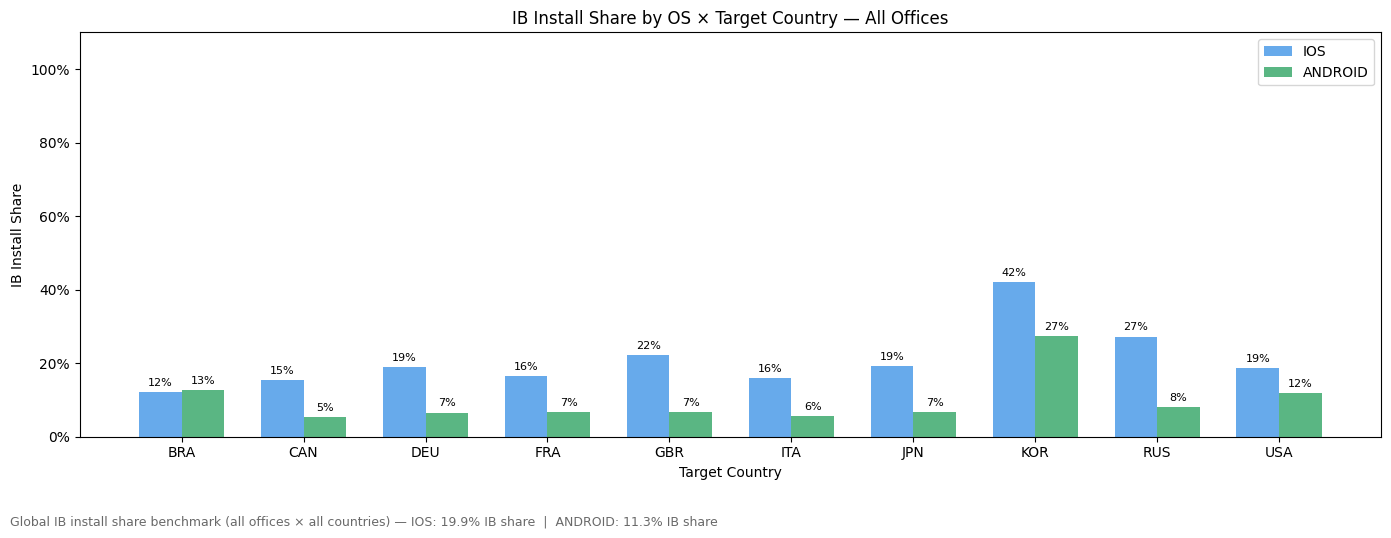

In [88]:
# IB install share by OS × target country — all offices aggregated
df_ib_share_all = (
    df_cr_mix_os
    .groupby(['country', 'os'])
    .agg(installs_ib=('installs_ib', 'sum'), installs=('installs', 'sum'))
    .assign(ib_share=lambda x: x['installs_ib'] / x['installs'])
    .reset_index()
)

# Global IB install share by OS (benchmark)
df_global_ib = (
    df_cr_mix_os
    .groupby('os')
    .agg(installs_ib=('installs_ib', 'sum'), installs=('installs', 'sum'))
    .assign(ib_share=lambda x: x['installs_ib'] / x['installs'])
)

countries_all = sorted(df_ib_share_all['country'].unique())
x = np.arange(len(countries_all))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))

for i, os_name in enumerate(['IOS', 'ANDROID']):
    vals = [
        df_ib_share_all.loc[
            (df_ib_share_all['country'] == c) & (df_ib_share_all['os'] == os_name),
            'ib_share'
        ].values[0] if ((df_ib_share_all['country'] == c) & (df_ib_share_all['os'] == os_name)).any() else float('nan')
        for c in countries_all
    ]
    bars = ax.bar(x + (i - 0.5) * width, vals, width, label=os_name,
                  color=colors[os_name], alpha=0.85)
    ax.bar_label(bars, fmt='{:.0%}', padding=3, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(countries_all)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.1)
ax.set_xlabel('Target Country')
ax.set_ylabel('IB Install Share')
ax.set_title('IB Install Share by OS × Target Country — All Offices')
ax.legend()
plt.tight_layout()

# Global IB install share benchmark text below chart
benchmark = '  |  '.join(
    f"{os_name}: {df_global_ib.loc[os_name, 'ib_share']:.1%} IB share"
    for os_name in ['IOS', 'ANDROID']
    if os_name in df_global_ib.index
)
fig.text(0.01, -0.04, f"Global IB install share benchmark (all offices × all countries) — {benchmark}",
         fontsize=9, color='dimgrey', va='top')

plt.show()

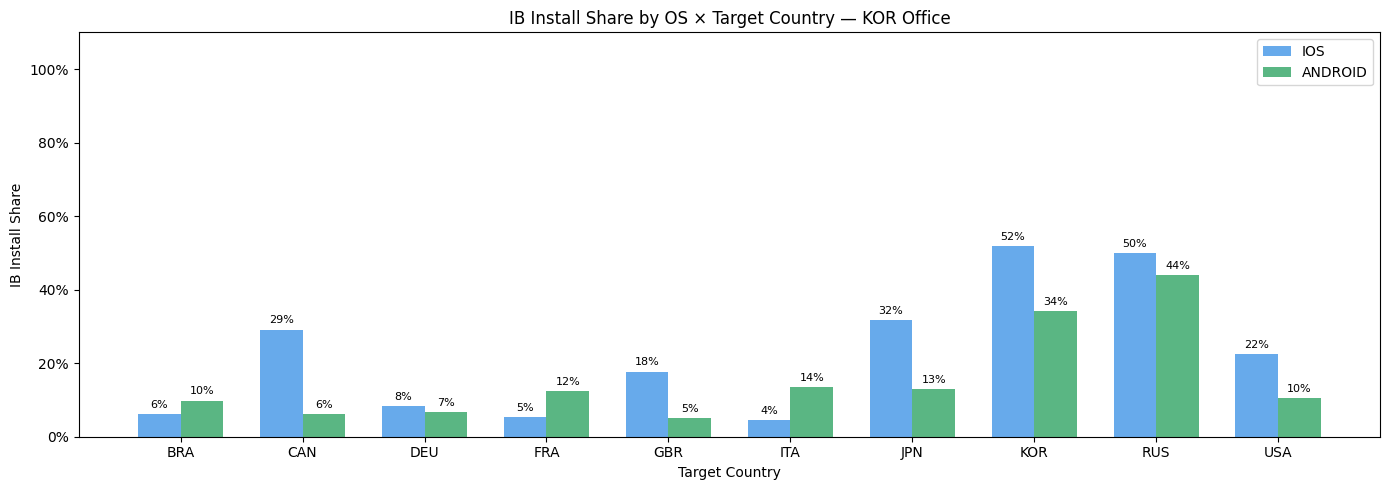

In [85]:
# IB install share by OS × target country — KOR office only
df_ib_share_country = (
    df_cr_mix_os[df_cr_mix_os['office'] == 'KOR']
    .groupby(['country', 'os'])
    .agg(installs_ib=('installs_ib', 'sum'), installs=('installs', 'sum'))
    .assign(ib_share=lambda x: x['installs_ib'] / x['installs'])
    .reset_index()
)

countries = sorted(df_ib_share_country['country'].unique())
os_list = ['IOS', 'ANDROID']
colors = {'IOS': '#4C9BE8', 'ANDROID': '#3DAA6D'}
x = np.arange(len(countries))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))

for i, os_name in enumerate(os_list):
    vals = [
        df_ib_share_country.loc[
            (df_ib_share_country['country'] == c) & (df_ib_share_country['os'] == os_name),
            'ib_share'
        ].values[0] if ((df_ib_share_country['country'] == c) & (df_ib_share_country['os'] == os_name)).any() else float('nan')
        for c in countries
    ]
    bars = ax.bar(x + (i - 0.5) * width, vals, width, label=os_name,
                  color=colors[os_name], alpha=0.85)
    ax.bar_label(bars, fmt='{:.0%}', padding=3, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(countries)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.1)
ax.set_xlabel('Target Country')
ax.set_ylabel('IB Install Share')
ax.set_title('IB Install Share by OS × Target Country — KOR Office')
ax.legend()
plt.tight_layout()
plt.show()